The libraries needed for image processing and graphics generation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.image import imread

# Set directories for training data
data_dir = 'inputs'
train_path = os.path.join(data_dir, 'train')
validation_path = os.path.join(data_dir, 'validation')
test_path = os.path.join(data_dir, 'test')

In [5]:
# Get the labels (folder names)
labels = os.listdir(train_path)
print(f"Project Labels: {labels}")

Project Labels: ['healthy', 'powdery_mildew']


In [9]:
# Create the outputs directory if it doesn't exist
if not os.path.exists('outputs/v1'):
    os.makedirs('outputs/v1')
    print("Directory 'outputs/v1' created!")

Image Size Analysis

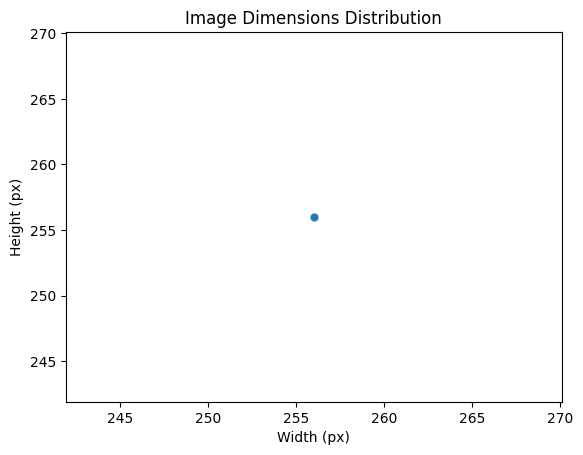

Average Image Shape: (256, 256, 3)


['outputs/v1/image_shape.pkl']

In [10]:
dim1, dim2 = [], []
for label in labels:
    for image_filename in os.listdir(os.path.join(train_path, label)):
        img = imread(os.path.join(train_path, label, image_filename))
        d1, d2, colors = img.shape
        dim1.append(d1) # height
        dim2.append(d2) # width

# Visualize the distribution of dimensions
sns.scatterplot(x=dim2, y=dim1, alpha=0.1)
plt.title('Image Dimensions Distribution')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.show()

# Calculate the average dimensions
image_shape = (int(np.mean(dim1)), int(np.mean(dim2)), 3)
print(f"Average Image Shape: {image_shape}")

# Save the image shape for later use in model training
joblib.dump(value=image_shape, filename="outputs/v1/image_shape.pkl")

Viewing the "Average Image"

--- Analyzing Label: healthy ---


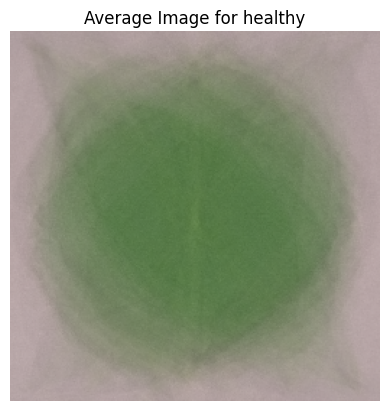

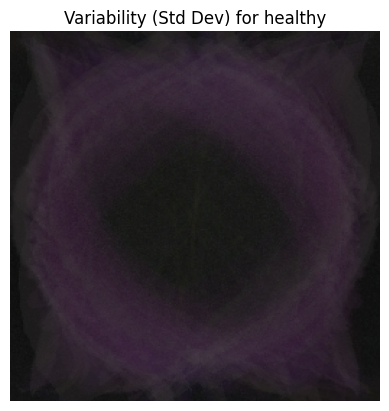

--- Analyzing Label: powdery_mildew ---


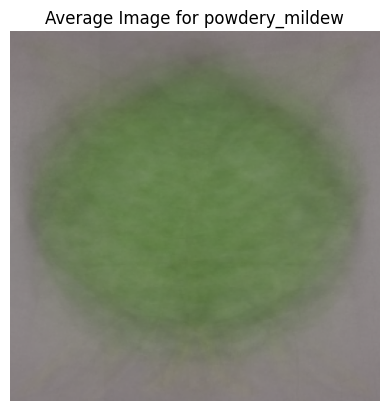

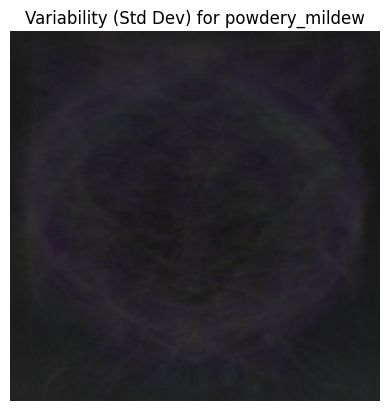

In [11]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np
import os

def load_image_as_array(directory, label, n_images=20):
    """
    Loads a subset of images and converts them to a numpy array.
    """
    images = []
    path = os.path.join(directory, label)
    # Take the first n_images for analysis
    for img_file in os.listdir(path)[:n_images]:
        img = imread(os.path.join(path, img_file))
        images.append(img)
    return np.array(images)

def calculate_average_and_variability(images):
    """
    Calculates the mean and standard deviation of a set of images.
    """
    avg_img = np.mean(images, axis=0)
    std_img = np.std(images, axis=0)
    return avg_img, std_img

# Analyze both labels
for label in labels:
    print(f"--- Analyzing Label: {label} ---")
    images = load_image_as_array(train_path, label, n_images=50)
    avg, std = calculate_average_and_variability(images)
    
    # Save the plots
    plt.imshow(avg.astype(np.uint8))
    plt.title(f'Average Image for {label}')
    plt.axis('off')
    plt.show()
    
    plt.imshow(std.astype(np.uint8))
    plt.title(f'Variability (Std Dev) for {label}')
    plt.axis('off')
    plt.show()

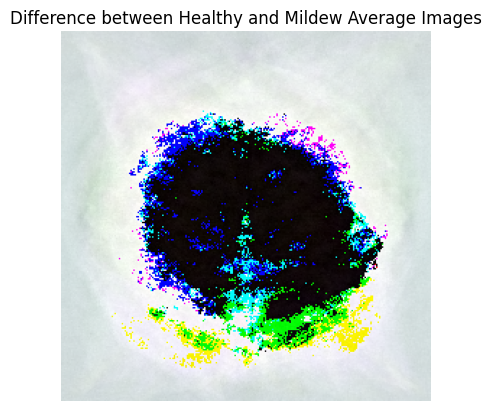

In [12]:
# Calculate the difference between the two averages
avg_healthy = load_image_as_array(train_path, 'healthy', n_images=50).mean(axis=0)
avg_mildew = load_image_as_array(train_path, 'powdery_mildew', n_images=50).mean(axis=0)

diff_img = avg_mildew - avg_healthy

plt.imshow(diff_img.astype(np.uint8))
plt.title('Difference between Healthy and Mildew Average Images')
plt.axis('off')
plt.show()